# Cohort, Funnerl, Retention 코드 직접 실습
캐글에 있는 user event 데이털르 바타응로 코호트, 퍼널, 리텐션 데이터 실습

In [1]:
import pandas as pd
df = pd.read_csv('C:/Users/USER/Desktop/TIL_new/data_analyst_practice/events.csv')

In [2]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ
...,...,...,...,...,...,...,...,...,...
885124,2021-02-28 23:55:01 UTC,view,953226,2144415927553229037,NaN,NaN,219.94,1515915625611023730,FRLqIttxKU
885125,2021-02-28 23:58:05 UTC,view,1715907,2144415927049912542,electronics.video.tv,starwind,80.03,1515915625611024014,g6WqPf50Ma
885126,2021-02-28 23:58:09 UTC,view,4170534,2144415939364389423,electronics.clocks,amazfit,64.92,1515915625611024020,xNIJBqZdkd
885127,2021-02-28 23:58:14 UTC,view,888273,2144415921932861531,electronics.telephone,NaN,10.16,1515915625611024030,9pCbKMIcSx


88만 건 정도의 큰 데이터다. 우선 어떤 이벤트가 있었는지 그것을 확인해보고 하나의 user id만 지정해서 데이터의 패턴부터 파악하자

In [3]:
df['event_type'].value_counts()

view        793748
cart         54035
purchase     37346
Name: event_type, dtype: int64

view -> cart -> purchase의 구조로 되어있다.
즉, 상품을 보았을 때, 그 상품이 cart로 들어간 횟수, 그리고 purchase로 어떻게 이어졌는지를 봐야한다.

In [4]:
df.loc[df.user_id == 1515915625519388267]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.9,1515915625519388267,LJuJVLEjPT


다음과 같이 상품만 보고 나가는 이탈 유저도 존재하는 것을 알 수 있다.

In [5]:
df.loc[df.user_id == 1515915625519380411]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
83,2020-09-24 12:15:11 UTC,view,627054,2144415926806642904,computers.components.power_supply,NaN,54.59,1515915625519380411,tdicluNnRY
102,2020-09-24 12:19:57 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY


In [6]:
df.loc[df.user_id == 1515915625610973155]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
884183,2021-02-28 19:13:22 UTC,view,3829912,2144415923107266682,computers.peripherals.printer,pantum,122.86,1515915625610973155,CxMKMQDRAN
884194,2021-02-28 19:15:40 UTC,view,3829913,2144415923107266682,computers.peripherals.printer,pantum,116.05,1515915625610973155,CxMKMQDRAN
884999,2021-02-28 22:56:17 UTC,view,3829913,2144415923107266682,computers.peripherals.printer,pantum,116.05,1515915625610973155,CxMKMQDRAN
885012,2021-02-28 23:01:14 UTC,view,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN
885015,2021-02-28 23:02:38 UTC,view,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN
885020,2021-02-28 23:03:42 UTC,cart,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN
885045,2021-02-28 23:08:57 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN
885078,2021-02-28 23:20:48 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN
885082,2021-02-28 23:23:11 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN
885090,2021-02-28 23:26:07 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN


하나의 세션 내에서 view 이후, product_id가 같은 것을 카트에 넣고, 이것을 구매하는 방식으로 이뤄진다.
문제는 이 세션의 시점이 어떻게 되는지를 좀 봐야 한다.

In [7]:
df.loc[df.event_type == 'purchase']

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
45,2020-09-24 12:04:10 UTC,purchase,1507291,2144415926806642904,computers.components.power_supply,supermicro,217.57,1515915625519390468,xn6SHCnZtk
82,2020-09-24 12:15:06 UTC,purchase,822426,2144415922360680550,computers.peripherals.camera,logitech,123.35,1515915625513574486,2gngxS29Ts
100,2020-09-24 12:19:01 UTC,purchase,4060928,2144415927049912542,electronics.video.tv,NaN,89.22,1515915625518130982,3yFCkx2KKW
132,2020-09-24 12:25:18 UTC,purchase,4060928,2144415927049912542,electronics.video.tv,NaN,89.22,1515915625518130982,3yFCkx2KKW
150,2020-09-24 12:29:49 UTC,purchase,1283197,2144415973413749245,computers.peripherals.nas,zyxel,123.79,1515915625519356010,3jFpdbozOd
...,...,...,...,...,...,...,...,...,...
885070,2021-02-28 23:16:45 UTC,purchase,4154620,2144415922427789416,computers.components.videocards,msi,656.63,1515915625596749373,h4fcX0qpOc
885078,2021-02-28 23:20:48 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN
885082,2021-02-28 23:23:11 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN
885090,2021-02-28 23:26:07 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN


In [8]:
df.loc[df.user_id == 1515915625596749373]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
674657,2021-01-24 22:19:07 UTC,view,4183863,2144415922427789416,computers.components.videocards,palit,577.60,1515915625596749373,6VPBcEnipq
674659,2021-01-24 22:19:20 UTC,view,4183863,2144415922427789416,computers.components.videocards,palit,577.60,1515915625596749373,6VPBcEnipq
872428,2021-02-26 13:47:06 UTC,view,1830099,2144415922427789416,computers.components.videocards,palit,486.81,1515915625596749373,h4fcX0qpOc
885060,2021-02-28 23:14:04 UTC,view,1821813,2144415922427789416,computers.components.videocards,NaN,397.48,1515915625596749373,h4fcX0qpOc
885065,2021-02-28 23:15:04 UTC,view,4154620,2144415922427789416,computers.components.videocards,msi,656.63,1515915625596749373,h4fcX0qpOc
885066,2021-02-28 23:15:30 UTC,cart,4154620,2144415922427789416,computers.components.videocards,msi,656.63,1515915625596749373,h4fcX0qpOc
885070,2021-02-28 23:16:45 UTC,purchase,4154620,2144415922427789416,computers.components.videocards,msi,656.63,1515915625596749373,h4fcX0qpOc


중요한 것은, 이렇게 세션별로 다르다는 것이다. 즉 하나의 세션 내에서 view, view->cart, view->cart->purchase가 잘 이뤄졌는지를 확인하는 것도 중요할 것이다. 정확히는 세션단위, 세션 내 상품단위 등등으로 우선은 퍼널을 따질 수 있을 것이다.

하지만 상품 단위로 보기에는 유저가 특정 상품에 대한 선택을 하는 것이기에 "서비스"의 분석에서는 세션 단위가 중요할 것이다.

## 한 세션 단위의 상품 구매
하나의 세션에서 여러 상품들을 구매하다가 하나 또는 여러개의 상품을 골라서 구매가 이루어 졌는지를 확인할 수 있다.
세션 단위로 이것을 해결해보자.

In [9]:
session_list = pd.DataFrame(df.groupby('user_session')['event_type'].apply(list).reset_index(drop = True))

In [10]:
session_list['event_type'] = session_list.event_type.apply(lambda x : list(set(x)))

In [11]:
session_list['event_type'].value_counts()

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


[view]                    445546
[cart, purchase, view]     20754
[cart, view]               20502
[purchase]                  2024
[purchase, view]            1558
[cart, purchase]               8
[cart]                         6
Name: event_type, dtype: int64

여러 패턴이 있는데

- 상품을 보기만 한 사람
- 상품을 보고 카트에 넣기만 한 사람
- 상품을 보고 카트에 넣고 구매한 사람
- 상품을 안보고 카트에 넣기만 한 사람
- 상품을 안보고 카트에 넣고 구매한 사람
- 상품을 보고 카트에 안넣고 바로 구매한 사람
- 상품을 안보고 카트에도 안넣고 바로 구매한 사람

총 7가지 경우가 있다. 마지막 1가지는 아무것도 안 한 사람인데 그 경우 로그에 잡힐 리가 없어 이렇게 7가지 분류임이 명백하다.

즉 상품 구경만 한 세션 -> 445,446건
상품 구경 + 카트  ->  20,502건 + 20,754건
상품 구경 + 구매 -> 20,754건

이렇게 분류할 수 있다. 나머지 케이스는 소수이거니와 구매->거래 혹은 직거래 등의 케이스는 굳이 고려하지 않도록 하자.

In [12]:
df_funnel = pd.DataFrame([['view', 445446], ['cart', 20502+20754], ['purchase', 20754]], columns = ['event', 'user_count'])

In [13]:
df_funnel

,event,user_count
0,view,445446
1,cart,41256
2,purchase,20754


퍼널율을 계산하면 다음과 같다.

In [14]:
df_funnel['funnel_rate'] = df_funnel.user_count.apply(lambda x : x/445446 * 100)

In [15]:
df_funnel

,event,user_count,funnel_rate
0,view,445446,100.000000
1,cart,41256,9.261729
2,purchase,20754,4.659151


9% 정도의 세션 건만이 장바구니 담기에 이어질 정도로 퍼널의 상황이 좋지 아니하다.
장바구니->구매도 약 50% 정도의 이탈이 발생하여 이탈율이 높으나  상품 뷰 -> 장바구니 쪽의 퍼널에 대한 개선이 시급함을 알 수 있다.

## 리텐션

### 유저 활동 리텐션

우선 유저가 유의미한 활동을 하였는지 리텐션을 부려고 한다.
purchase던, view던, cart던 활동이 한 적 있는 유저를 모으고, 리텐션을 계산하자.

이를 위해서는 각 월별로 유저 활동 리스트를 가져오려고 한다.

In [16]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ
...,...,...,...,...,...,...,...,...,...
885124,2021-02-28 23:55:01 UTC,view,953226,2144415927553229037,NaN,NaN,219.94,1515915625611023730,FRLqIttxKU
885125,2021-02-28 23:58:05 UTC,view,1715907,2144415927049912542,electronics.video.tv,starwind,80.03,1515915625611024014,g6WqPf50Ma
885126,2021-02-28 23:58:09 UTC,view,4170534,2144415939364389423,electronics.clocks,amazfit,64.92,1515915625611024020,xNIJBqZdkd
885127,2021-02-28 23:58:14 UTC,view,888273,2144415921932861531,electronics.telephone,NaN,10.16,1515915625611024030,9pCbKMIcSx


In [17]:
df['date_month'] = df.event_time.apply(lambda x : str(x)[0:7])

우리가 보려는 것은 활동 관련이므로 groupby를 해서 list를 만들어 버리자

In [32]:
df_ret = pd.DataFrame(df[['user_id', 'date_month']].groupby('date_month').apply(lambda x : list(set(x['user_id'])))).reset_index(drop=False)

In [34]:
df_ret.columns = ['date_month','user_list']

In [35]:
df_ret

,date_month,user_list
0,2020-09,"[1515915625477767168, 1515915625519841283, 151..."
1,2020-10,"[1515915625525149704, 1515915625530916875, 151..."
2,2020-11,"[1515915625539567616, 1515915625538519042, 151..."
3,2020-12,"[1515915625547169793, 1515915625561718785, 151..."
4,2021-01,"[1515915625598025743, 1515915625591472149, 151..."
5,2021-02,"[1515915625606938625, 1515915625606389913, 151..."


다음과 같이 월과 활동한 유저 명단을 가져올 수 있다.

In [57]:
import numpy as np
ret_list = []
for i in range(len(df_ret)):
    print(i)
    cur_ret = []
    cur_cohort = list(df_ret['user_list'][i])
    cur_cohort_user = len(cur_cohort)
    for j in range(i, len(df_ret)):
        if i == j:
            cur_ret.append(100)
        else:
            cur_user = list(df_ret['user_list'][j])
            count = len(list(set(cur_cohort) & set(cur_user)))
            cur_ret.append(round(count/cur_cohort_user*100, 2))
    while len(cur_ret) < len(df_ret):
        cur_ret.append(np.nan)
    ret_list.append(cur_ret)

0
1
2
3
4
5


In [58]:
ret_list

[[100, 6.23, 1.74, 0.78, 0.64, 0.47],
 [100, 2.83, 0.9, 0.6, 0.38, nan],
 [100, 2.38, 1.07, 0.74, nan, nan],
 [100, 2.81, 1.3, nan, nan, nan],
 [100, 3.23, nan, nan, nan, nan],
 [100, nan, nan, nan, nan, nan]]

구매 리텐션으로 살펴보자.

In [62]:
df_buy = df.loc[df.event_type == 'purchase']


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date_month
45,2020-09-24 12:04:10 UTC,purchase,1507291,2144415926806642904,computers.components.power_supply,supermicro,217.57,1515915625519390468,xn6SHCnZtk,2020-09
82,2020-09-24 12:15:06 UTC,purchase,822426,2144415922360680550,computers.peripherals.camera,logitech,123.35,1515915625513574486,2gngxS29Ts,2020-09
100,2020-09-24 12:19:01 UTC,purchase,4060928,2144415927049912542,electronics.video.tv,NaN,89.22,1515915625518130982,3yFCkx2KKW,2020-09
132,2020-09-24 12:25:18 UTC,purchase,4060928,2144415927049912542,electronics.video.tv,NaN,89.22,1515915625518130982,3yFCkx2KKW,2020-09
150,2020-09-24 12:29:49 UTC,purchase,1283197,2144415973413749245,computers.peripherals.nas,zyxel,123.79,1515915625519356010,3jFpdbozOd,2020-09
...,...,...,...,...,...,...,...,...,...,...
885070,2021-02-28 23:16:45 UTC,purchase,4154620,2144415922427789416,computers.components.videocards,msi,656.63,1515915625596749373,h4fcX0qpOc,2021-02
885078,2021-02-28 23:20:48 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN,2021-02
885082,2021-02-28 23:23:11 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN,2021-02
885090,2021-02-28 23:26:07 UTC,purchase,500058,2144415923107266682,computers.peripherals.printer,pantum,67.00,1515915625610973155,CxMKMQDRAN,2021-02


In [68]:
df_ret = pd.DataFrame(df_buy[['user_id', 'date_month']].groupby('date_month').apply(lambda x : list(set(x['user_id'])))).reset_index(drop=False)
df_ret.columns = ['date_month','user_list']

ret_list = []
for i in range(len(df_ret)):
    print(i)
    cur_ret = []
    cur_cohort = list(df_ret['user_list'][i])
    cur_cohort_user = len(cur_cohort)
    for j in range(i, len(df_ret)):
        if i == j:
            cur_ret.append(100)
        else:
            cur_user = list(df_ret['user_list'][j])
            count = len(list(set(cur_cohort) & set(cur_user)))
            cur_ret.append(round(count/cur_cohort_user*100, 2))
    while len(cur_ret) < len(df_ret):
        cur_ret.append(np.nan)
    ret_list.append(cur_ret)

0
1
2
3
4
5


In [64]:
ret_list

[[100, 3.83, 0.8, 0.32, 0.16, 0.0],
 [100, 1.77, 0.45, 0.11, 0.11, nan],
 [100, 1.62, 0.62, 0.18, nan, nan],
 [100, 1.99, 0.62, nan, nan, nan],
 [100, 2.56, nan, nan, nan, nan],
 [100, nan, nan, nan, nan, nan]]

첫 구매 이후 지속적인 구매 자체가 안 이뤄지고 있다. 시각화를 끝으로 마무리해보자

In [70]:
ret_heat_df = pd.DataFrame(ret_list, columns = [0, 1, 2, 3, 4, 5],index = list(df_ret['date_month']))

<AxesSubplot:>

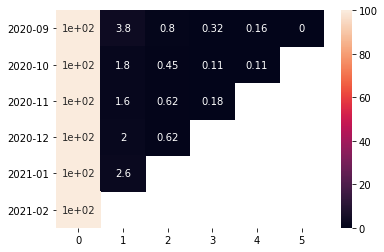

In [73]:
import seaborn as sns
sns.heatmap(ret_heat_df, annot = True)